In [8]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\somil\Downloads\sales-analytics
['.ipynb_checkpoints', 'sales-analysis.ipynb', 'superstore-sales-analytics.ipynb']


In [9]:
import os
print(os.listdir())


['.ipynb_checkpoints', 'sales-analysis.ipynb', 'Sample - Superstore.csv']


In [10]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Sample - Superstore.csv', encoding='latin-1')

# See the first 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
# See how many rows and columns we have
print("Shape:", df.shape)

# See all column names
print("\nColumns:", df.columns.tolist())

# See a summary of the data
df.info()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null

In [12]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Fix the date columns (convert from text to proper dates)
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print("\nDates fixed! Ready for analysis ✅")

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 0

Dates fixed! Ready for analysis ✅


In [13]:
# ---- QUESTION 1: What is the Total Revenue, Profit and Quantity Sold? ----
print("===== BUSINESS OVERVIEW =====")
print(f"Total Sales Revenue: ${df['Sales'].sum():,.2f}")
print(f"Total Profit:        ${df['Profit'].sum():,.2f}")
print(f"Total Orders:        {df['Order ID'].nunique()}")
print(f"Total Items Sold:    {df['Quantity'].sum()}")

===== BUSINESS OVERVIEW =====
Total Sales Revenue: $2,297,200.86
Total Profit:        $286,397.02
Total Orders:        5009
Total Items Sold:    37873


In [14]:
# ---- QUESTION 2: Which Category generates the most Sales and Profit? ----
print("===== SALES & PROFIT BY CATEGORY =====")
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
category_summary['Profit Margin %'] = (category_summary['Profit'] / category_summary['Sales'] * 100).round(2)
print(category_summary)

===== SALES & PROFIT BY CATEGORY =====
                       Sales       Profit  Profit Margin %
Category                                                  
Technology       836154.0330  145454.9481            17.40
Furniture        741999.7953   18451.2728             2.49
Office Supplies  719047.0320  122490.8008            17.04


In [15]:
# ---- QUESTION 3: Which Region performs best? ----
print("===== SALES & PROFIT BY REGION =====")
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
region_summary['Profit Margin %'] = (region_summary['Profit'] / region_summary['Sales'] * 100).round(2)
print(region_summary)

===== SALES & PROFIT BY REGION =====
               Sales       Profit  Profit Margin %
Region                                            
West     725457.8245  108418.4489            14.94
East     678781.2400   91522.7800            13.48
South    391721.9050   46749.4303            11.93
Central  501239.8908   39706.3625             7.92


In [16]:
# ---- QUESTION 4: What is the Monthly Sales Trend? ----
print("===== MONTHLY SALES TREND =====")
df['Month-Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month-Year')['Sales'].sum()
print(monthly_sales)

===== MONTHLY SALES TREND =====
Month-Year
2014-01     14236.8950
2014-02      4519.8920
2014-03     55691.0090
2014-04     28295.3450
2014-05     23648.2870
2014-06     34595.1276
2014-07     33946.3930
2014-08     27909.4685
2014-09     81777.3508
2014-10     31453.3930
2014-11     78628.7167
2014-12     69545.6205
2015-01     18174.0756
2015-02     11951.4110
2015-03     38726.2520
2015-04     34195.2085
2015-05     30131.6865
2015-06     24797.2920
2015-07     28765.3250
2015-08     36898.3322
2015-09     64595.9180
2015-10     31404.9235
2015-11     75972.5635
2015-12     74919.5212
2016-01     18542.4910
2016-02     22978.8150
2016-03     51715.8750
2016-04     38750.0390
2016-05     56987.7280
2016-06     40344.5340
2016-07     39261.9630
2016-08     31115.3743
2016-09     73410.0249
2016-10     59687.7450
2016-11     79411.9658
2016-12     96999.0430
2017-01     43971.3740
2017-02     20301.1334
2017-03     58872.3528
2017-04     36521.5361
2017-05     44261.1102
2017-06     52

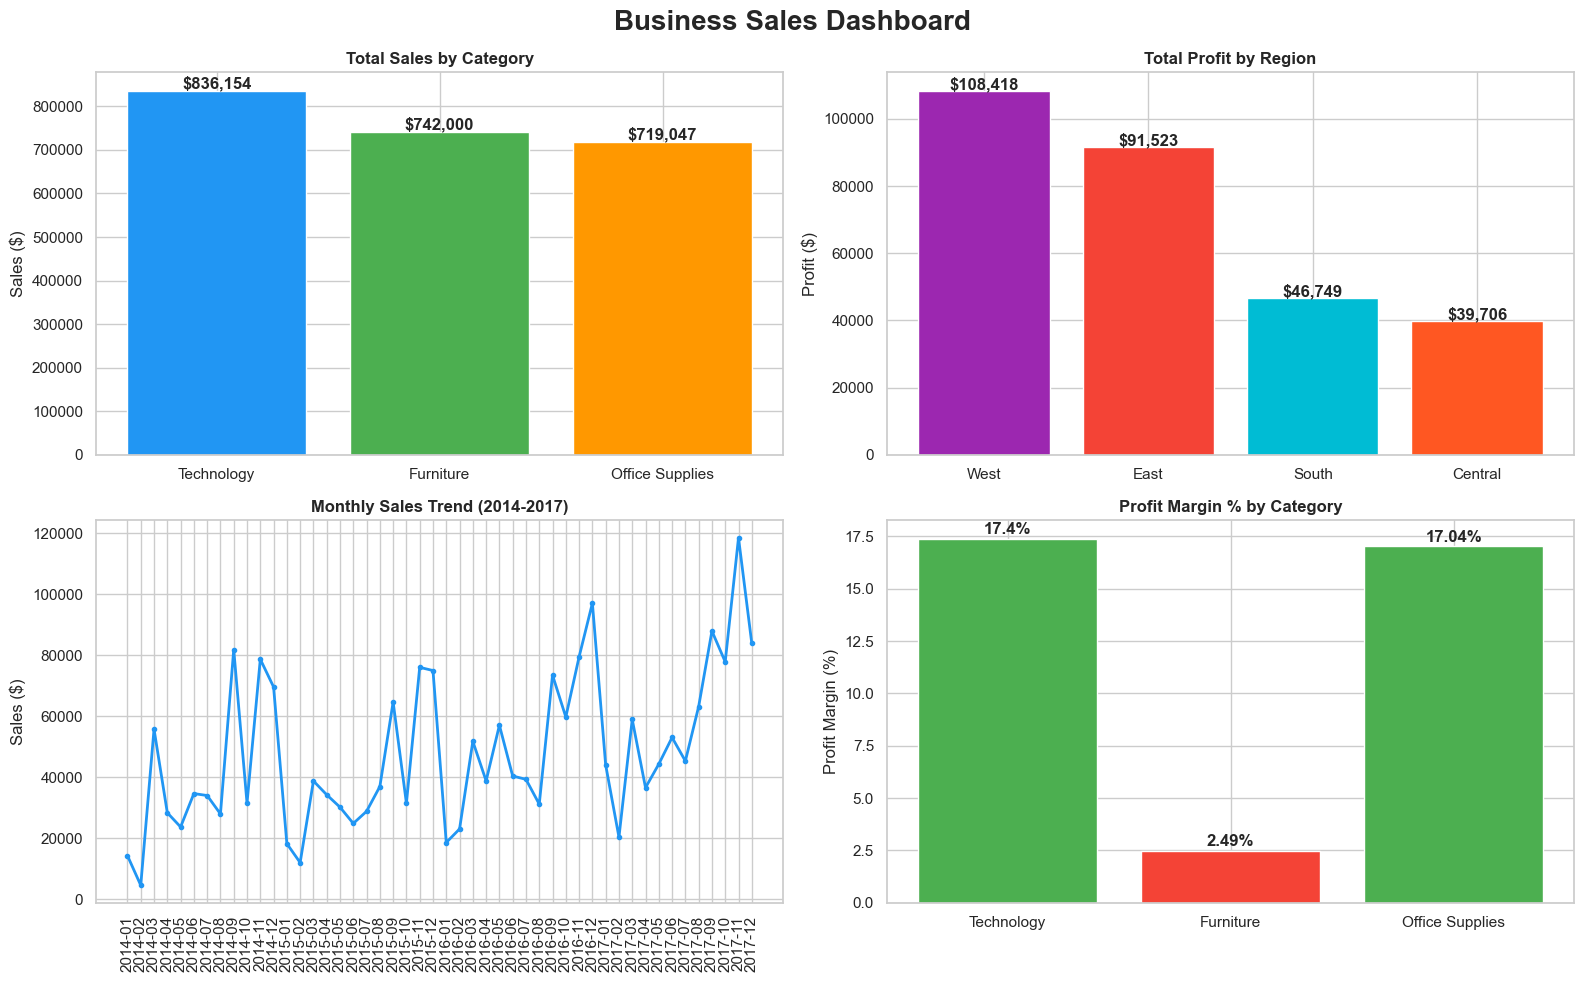

Dashboard saved as sales_dashboard.png ✅


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Business Sales Dashboard', fontsize=20, fontweight='bold')

# ---- CHART 1: Sales by Category ----
axes[0, 0].bar(category_summary.index, category_summary['Sales'], color=['#2196F3', '#4CAF50', '#FF9800'])
axes[0, 0].set_title('Total Sales by Category', fontweight='bold')
axes[0, 0].set_ylabel('Sales ($)')
for i, v in enumerate(category_summary['Sales']):
    axes[0, 0].text(i, v + 5000, f'${v:,.0f}', ha='center', fontweight='bold')

# ---- CHART 2: Profit by Region ----
axes[0, 1].bar(region_summary.index, region_summary['Profit'], color=['#9C27B0', '#F44336', '#00BCD4', '#FF5722'])
axes[0, 1].set_title('Total Profit by Region', fontweight='bold')
axes[0, 1].set_ylabel('Profit ($)')
for i, v in enumerate(region_summary['Profit']):
    axes[0, 1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold')

# ---- CHART 3: Monthly Sales Trend ----
monthly_values = monthly_sales.values
monthly_labels = [str(m) for m in monthly_sales.index]
axes[1, 0].plot(monthly_labels, monthly_values, color='#2196F3', linewidth=2, marker='o', markersize=3)
axes[1, 0].set_title('Monthly Sales Trend (2014-2017)', fontweight='bold')
axes[1, 0].set_ylabel('Sales ($)')
axes[1, 0].tick_params(axis='x', rotation=90)

# ---- CHART 4: Profit Margin by Category ----
colors = ['#4CAF50' if x > 10 else '#F44336' for x in category_summary['Profit Margin %']]
axes[1, 1].bar(category_summary.index, category_summary['Profit Margin %'], color=colors)
axes[1, 1].set_title('Profit Margin % by Category', fontweight='bold')
axes[1, 1].set_ylabel('Profit Margin (%)')
for i, v in enumerate(category_summary['Profit Margin %']):
    axes[1, 1].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('sales_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as sales_dashboard.png ✅")

In [20]:
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment

# Create Excel writer
writer = pd.ExcelWriter('sales_report.xlsx', engine='openpyxl')

# Sheet 1: Business Overview
overview_data = {
    'Metric': ['Total Sales Revenue', 'Total Profit', 'Total Orders', 'Total Items Sold'],
    'Value': [f'${df["Sales"].sum():,.2f}', f'${df["Profit"].sum():,.2f}', 
              df['Order ID'].nunique(), df['Quantity'].sum()]
}
pd.DataFrame(overview_data).to_excel(writer, sheet_name='Overview', index=False)

# Sheet 2: Category Analysis
category_summary.to_excel(writer, sheet_name='By Category')

# Sheet 3: Region Analysis
region_summary.to_excel(writer, sheet_name='By Region')

# Sheet 4: Monthly Trend
monthly_sales.to_frame().to_excel(writer, sheet_name='Monthly Trend')

writer.close()
print("Excel report saved as sales_report.xlsx ✅")

Excel report saved as sales_report.xlsx ✅
